## ISEL
### LEIM CSM TP3

Alunos: 
- Lucas Santos 52325
- Francisco Soares 52648

Turma 42D

In [68]:
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

In [69]:

notebook_path = os.getcwd()

if notebook_path.endswith('lab4'):
    folder_name = 'carro_seq'
else:
    folder_name = 'lab4/carro_seq'
try:
    files = sorted([f for f in os.listdir(folder_name) if f.endswith(('.png', '.jpg', '.jpeg', '.tiff'))])
    print(f"Sucesso! Encontradas {len(files)} imagens na pasta.")
except FileNotFoundError:
    files = []



Sucesso! Encontradas 11 imagens na pasta.


## A

In [70]:
def medir_taxa_compressao(frame_original, buffer_comprimido):
    # .size dá diretamente o número total de píxeis (Largura * Altura)
    # Como cada píxel em grayscale é 1 byte, isto equivale ao tamanho em bytes.
    tamanho_original = frame_original.size
    
    # Tamanho comprimido: número de bytes no buffer do imencode
    tamanho_comprimido = len(buffer_comprimido)
    
    # Taxa = Tamanho Original / Tamanho Comprimido
    taxa = tamanho_original / tamanho_comprimido
    return taxa

In [71]:
qualidade = 80
encode_param = [int(cv.IMWRITE_JPEG_QUALITY), qualidade]

# Lista para acumular os dicionários com os dados de cada frame
dados_projeto = []

# 2. Correr o loop pelas imagens listadas na Célula 1
for filename in files:
    file_path = os.path.join(folder_name, filename)
    frame = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    
    if frame is not None:
        # Simular a compressão gerando o buffer de bytes
        sucesso, buffer_comprimido = cv.imencode('.jpg', frame, encode_param)
        
        if sucesso:
            # Chamar a função definida na Célula 2
            taxa = medir_taxa_compressao(frame, buffer_comprimido)
            
            # Guardar as informações num dicionário
            dados_projeto.append({
                'Ficheiro': filename,
                'Tam. Original (bytes)': frame.size,
                'Tam. Comprimido (bytes)': len(buffer_comprimido),
                'Taxa Compressão': round(taxa, 2)
            })
    else:
        print(f"Erro ao ler {filename}")

# 3. Criar o DataFrame do Pandas
df_resultados = pd.DataFrame(dados_projeto)

# 4. Exibir a tabela formatada no Notebook
df_resultados


,Ficheiro,Tam. Original (bytes),Tam. Comprimido (bytes),Taxa Compressão
0,carro_1.tiff,65536,10444,6.27
1,carro_10.tiff,65536,10737,6.10
2,carro_11.tiff,65536,10908,6.01
3,carro_2.tiff,65536,10519,6.23
4,carro_3.tiff,65536,10558,6.21
5,carro_4.tiff,65536,10751,6.10
6,carro_5.tiff,65536,10808,6.06
7,carro_6.tiff,65536,10787,6.08
8,carro_7.tiff,65536,10839,6.05
9,carro_8.tiff,65536,10673,6.14


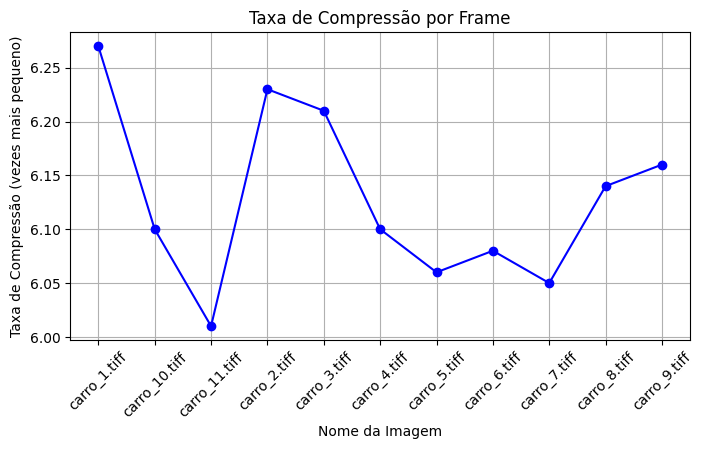

In [72]:


# 1. Definir o tamanho do gráfico
plt.figure(figsize=(8, 4))

# 2. Desenhar a linha com bolinhas nos pontos
plt.plot(df_resultados['Ficheiro'], df_resultados['Taxa Compressão'], marker='o', color='blue')

# 3. Nomes dos eixos e título simples
plt.title('Taxa de Compressão por Frame')
plt.xlabel('Nome da Imagem')
plt.ylabel('Taxa de Compressão (vezes mais pequeno)')

# 4. Rodar os nomes das imagens para não ficarem uns em cima dos outros
plt.xticks(rotation=45)
plt.grid(True)

# 5. Mostrar o gráfico
plt.show()

## B

In [85]:
def medir_psnr(frame_original, frame_reconstruida):
    # 1. Calcular a diferença/erro quadrado entre as duas imagens
    mse = np.mean((frame_original.astype(np.float64) - frame_reconstruida.astype(np.float64)) ** 2)
    
    # 2. Se o erro for zero, as imagens são perfeitamente iguais
    if mse == 0:
        return 99.0 
    
    # 3. Fórmula padrão do PSNR para imagens de 8 bits (0-255)
    max_pixel = 255.0
    psnr = 10 * np.log10((max_pixel ** 2) / mse)
    return psnr

In [86]:
# Configuração da compressão (Qualidade 80)
qualidade = 50
encode_param = [int(cv.IMWRITE_JPEG_QUALITY), qualidade]

dados_psnr = []

# Loop pelas imagens da pasta
for filename in files:
    file_path = os.path.join(folder_name, filename)
    frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    
    if frame_original is not None:
        # EMISSOR: Comprime a imagem para bytes
        _, buffer = cv.imencode('.jpg', frame_original, encode_param)
        
        # RECETOR: Descomprime os bytes de volta para imagem
        frame_reconstruida = cv.imdecode(buffer, cv.IMREAD_GRAYSCALE)
        
        # Calcular a qualidade usando a função da Célula 1
        resultado_psnr = medir_psnr(frame_original, frame_reconstruida)
        
        # Guardar no dicionário
        dados_psnr.append({
            'Ficheiro': filename,
            'PSNR (dB)': round(resultado_psnr, 2)
        })

# Criar a tabela Pandas
df_psnr = pd.DataFrame(dados_psnr)
df_psnr

,Ficheiro,PSNR (dB)
0,carro_1.tiff,34.83
1,carro_10.tiff,34.58
2,carro_11.tiff,34.59
3,carro_2.tiff,34.66
4,carro_3.tiff,34.68
5,carro_4.tiff,34.70
6,carro_5.tiff,34.62
7,carro_6.tiff,34.60
8,carro_7.tiff,34.66
9,carro_8.tiff,34.69


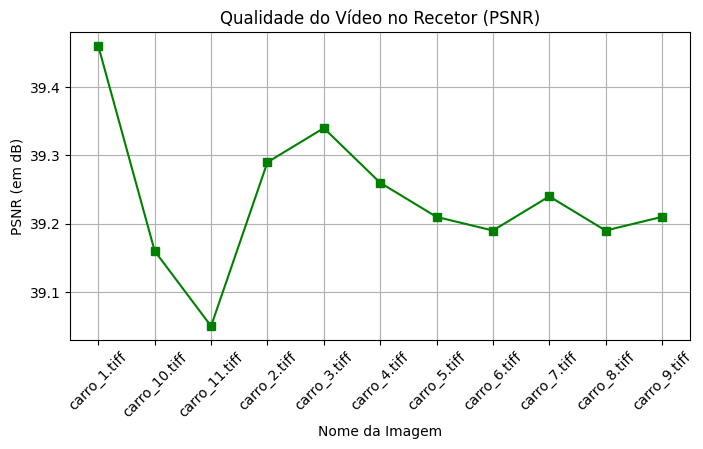

In [75]:

# 1. Criar o tamanho do gráfico
plt.figure(figsize=(8, 4))

# 2. Desenhar a linha do PSNR
plt.plot(df_psnr['Ficheiro'], df_psnr['PSNR (dB)'], marker='s', color='green')

# 3. Títulos simples
plt.title('Qualidade do Vídeo no Recetor (PSNR)')
plt.xlabel('Nome da Imagem')
plt.ylabel('PSNR (em dB)')

# 4. Ajustes visuais fáceis
plt.xticks(rotation=45)
plt.grid(True)

# 5. Mostrar
plt.show()

## C

In [ ]:
def medir_entropia(frame):
    # 1. Calcular o histograma (frequência de cada tom de cinzento)
    hist = cv.calcHist([frame], [0], None, [256], [0, 256])
    
    # 2. Converter as frequências em probabilidades (dividir pelo total de píxeis)
    probabilidades = hist.ravel() / frame.size
    
    # 3. Filtrar probabilidades maiores que zero para evitar o erro de log(0)
    probs_validas = probabilidades[probabilidades > 0]
    
    # 4. Aplicar a fórmula da Entropia de Shannon
    entropia = -np.sum(probs_validas * np.log2(probs_validas))
    return entropia

In [77]:


dados_entropia = []

# Loop pelas imagens da pasta
for filename in files:
    file_path = os.path.join(folder_name, filename)
    frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    
    if frame_original is not None:
        # Calcular a entropia da frame usando a função da Célula 1
        valor_entropia = medir_entropia(frame_original)
        
        # Guardar no dicionário
        dados_entropia.append({
            'Ficheiro': filename,
            'Entropia (bits/pixel)': round(valor_entropia, 2)
        })

# Criar a tabela Pandas
df_entropia = pd.DataFrame(dados_entropia)
df_entropia

,Ficheiro,Entropia (bits/pixel)
0,carro_1.tiff,6.81
1,carro_10.tiff,6.90
2,carro_11.tiff,6.92
3,carro_2.tiff,6.83
4,carro_3.tiff,6.84
5,carro_4.tiff,6.85
6,carro_5.tiff,6.87
7,carro_6.tiff,6.87
8,carro_7.tiff,6.89
9,carro_8.tiff,6.89


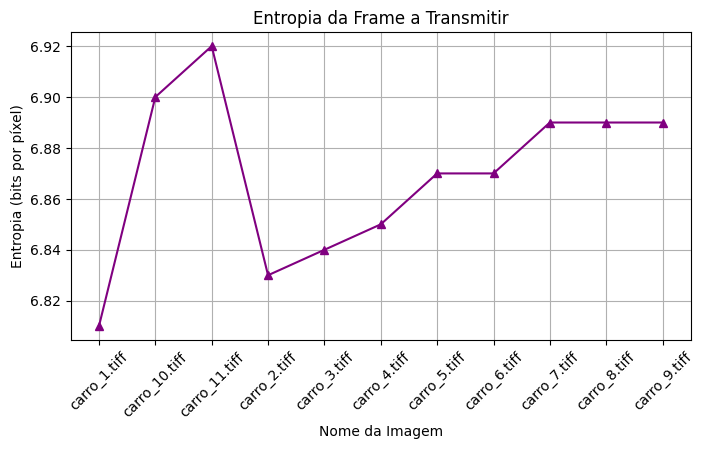

In [78]:


# 1. Criar o tamanho do gráfico
plt.figure(figsize=(8, 4))

# 2. Desenhar a linha da Entropia
plt.plot(df_entropia['Ficheiro'], df_entropia['Entropia (bits/pixel)'], marker='^', color='purple')

# 3. Títulos simples
plt.title('Entropia da Frame a Transmitir')
plt.xlabel('Nome da Imagem')
plt.ylabel('Entropia (bits por píxel)')

# 4. Ajustes visuais fáceis
plt.xticks(rotation=45)
plt.grid(True)

# 5. Mostrar
plt.show()

## D

In [79]:
def medir_energia_media(frame):
    # 1. Converter para float64 para permitir cálculos com números grandes
    frame_float = frame.astype(np.float64)
    
    # 2. Calcular o quadrado de cada píxel e tirar a média global
    energia = np.mean(frame_float ** 2)
    return energia

In [80]:
dados_energia = []

# Loop pelas imagens da pasta
for filename in files:
    file_path = os.path.join(folder_name, filename)
    frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    
    if frame_original is not None:
        # Calcular a energia média usando a função da Célula 1
        valor_energia = medir_energia_media(frame_original)
        
        # Guardar no dicionário
        dados_energia.append({
            'Ficheiro': filename,
            'Energia Média/Pixel': round(valor_energia, 2)
        })

# Criar a tabela Pandas
df_energia = pd.DataFrame(dados_energia)
df_energia

,Ficheiro,Energia Média/Pixel
0,carro_1.tiff,21931.49
1,carro_10.tiff,23853.52
2,carro_11.tiff,23938.93
3,carro_2.tiff,22170.28
4,carro_3.tiff,22371.39
5,carro_4.tiff,22613.18
6,carro_5.tiff,22990.23
7,carro_6.tiff,23261.13
8,carro_7.tiff,23549.17
9,carro_8.tiff,23697.38


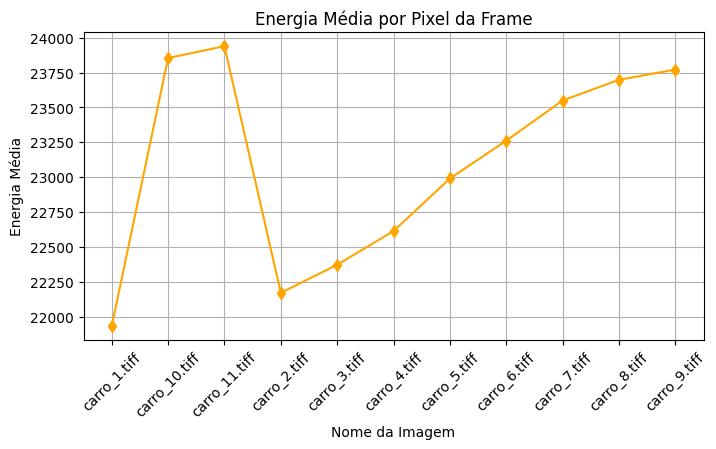

In [81]:
plt.figure(figsize=(8, 4))

# 2. Desenhar a linha da Energia
plt.plot(df_energia['Ficheiro'], df_energia['Energia Média/Pixel'], marker='d', color='orange')

# 3. Títulos simples
plt.title('Energia Média por Pixel da Frame')
plt.xlabel('Nome da Imagem')
plt.ylabel('Energia Média')

# 4. Ajustes visuais fáceis
plt.xticks(rotation=45)
plt.grid(True)

# 5. Mostrar
plt.show()

## E

In [82]:
import time


def medir_tempos_codec(frame, qualidade_jpeg=80):
    # 1. Medir tempo de Compressão (Emissor)
    t0 = time.perf_counter()
    sucesso, buffer = cv.imencode('.jpg', frame, [int(cv.IMWRITE_JPEG_QUALITY), qualidade_jpeg])
    t1 = time.perf_counter()
    
    tempo_compressao = (t1 - t0) * 1000 # Converter para milissegundos
    
    # 2. Medir tempo de Descompressão (Recetor)
    t2 = time.perf_counter()
    frame_reconstruida = cv.imdecode(buffer, cv.IMREAD_GRAYSCALE)
    t3 = time.perf_counter()
    
    tempo_descompressao = (t3 - t2) * 1000 # Converter para milissegundos
    
    return tempo_compressao, tempo_descompressao

In [83]:
dados_tempo = []

# Loop pelas imagens da pasta
for filename in files:
    file_path = os.path.join(folder_name, filename)
    frame_original = cv.imread(file_path, cv.IMREAD_GRAYSCALE)
    
    if frame_original is not None:
        # Calcular os tempos usando a função da Célula 1
        t_comp, t_decomp = medir_tempos_codec(frame_original, qualidade_jpeg=80)
        
        # Guardar no dicionário
        dados_tempo.append({
            'Ficheiro': filename,
            'Tempo Compressão (ms)': round(t_comp, 3),
            'Tempo Descompressão (ms)': round(t_decomp, 3)
        })

# Criar a tabela Pandas
df_tempos = pd.DataFrame(dados_tempo)
df_tempos

,Ficheiro,Tempo Compressão (ms),Tempo Descompressão (ms)
0,carro_1.tiff,0.703,0.534
1,carro_10.tiff,0.588,0.522
2,carro_11.tiff,0.382,0.363
3,carro_2.tiff,0.399,0.449
4,carro_3.tiff,0.337,0.358
5,carro_4.tiff,0.430,0.468
6,carro_5.tiff,0.393,0.478
7,carro_6.tiff,0.497,0.680
8,carro_7.tiff,0.622,0.456
9,carro_8.tiff,0.337,0.363


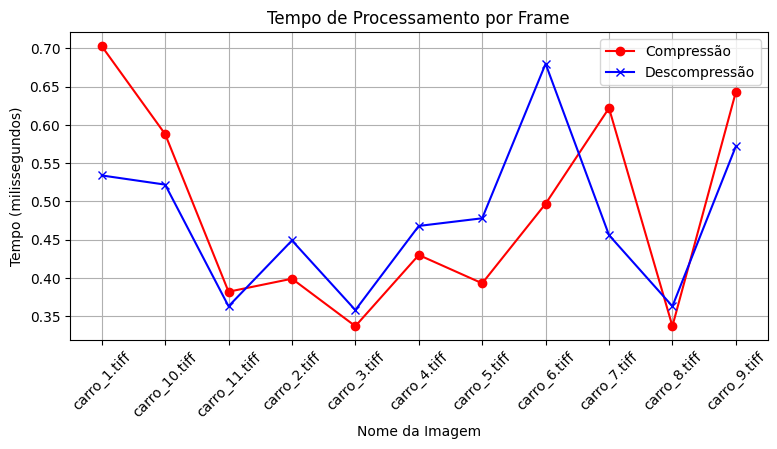

In [84]:

plt.figure(figsize=(9, 4))

# 2. Desenhar a linha de Compressão e a de Descompressão
plt.plot(df_tempos['Ficheiro'], df_tempos['Tempo Compressão (ms)'], marker='o', color='red', label='Compressão')
plt.plot(df_tempos['Ficheiro'], df_tempos['Tempo Descompressão (ms)'], marker='x', color='blue', label='Descompressão')

# 3. Títulos e Legenda
plt.title('Tempo de Processamento por Frame')
plt.xlabel('Nome da Imagem')
plt.ylabel('Tempo (milissegundos)')
plt.legend() # Mostra a legenda a identificar as linhas

# 4. Ajustes visuais fáceis
plt.xticks(rotation=45)
plt.grid(True)

# 5. Mostrar
plt.show()